In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

In [3]:
data = pd.read_excel(r"D:\upi fraud detection\upi_fraud_large_dataset_5000.xlsx")

print(data.head())
print(data.shape)
print(data.columns)

   trans_hour  trans_day  trans_month  trans_year  category  upi_number  \
0          10         28            3        2023         5  9957000000   
1           5         19            2        2023        12  9957000001   
2          18         27            3        2025        11  9957000002   
3          17         15            3        2024         6  9957000003   
4           3          8            1        2023         6  9957000004   

   trans_amt  state_code     zip  fraud_risk  
0    6835.26          13  662053           0  
1   10326.39          24  731985           0  
2    1580.18           5  849385           1  
3   11807.68          18  343979           0  
4   36992.72          17  535655           1  
(5000, 10)
Index(['trans_hour', 'trans_day', 'trans_month', 'trans_year', 'category',
       'upi_number', 'trans_amt', 'state_code', 'zip', 'fraud_risk'],
      dtype='object')


In [4]:
X = data.drop("fraud_risk", axis=1)
y = data["fraud_risk"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.877


In [8]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.846


In [9]:
svc = SVC()

svc.fit(X_train_scaled, y_train)

y_pred_svc = svc.predict(X_test_scaled)

print("SVC Accuracy:", accuracy_score(y_test, y_pred_svc))

SVC Accuracy: 0.893


In [10]:
nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.88


In [11]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.849


In [12]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.935


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

In [14]:
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense

model = Sequential()

model.add(Input(shape=(X_train_cnn.shape[1], 1)))

model.add(Conv1D(filters=32, kernel_size=2, activation='relu'))

model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dense(64, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_cnn, y_test)
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7985 - loss: 0.4813 - val_accuracy: 0.8200 - val_loss: 0.4384
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8388 - loss: 0.4123 - val_accuracy: 0.8660 - val_loss: 0.4110
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8562 - loss: 0.3924 - val_accuracy: 0.8550 - val_loss: 0.3940
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8717 - loss: 0.3726 - val_accuracy: 0.8740 - val_loss: 0.3729
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8802 - loss: 0.3597 - val_accuracy: 0.8710 - val_loss: 0.3598
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8850 - loss: 0.3478 - val_accuracy: 0.8750 - val_loss: 0.3565
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8827 - loss: 0.3442 - val_accuracy: 0.8810 - val_loss: 0.3428
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8895 - loss: 0.3342 - val_accura

In [18]:
loss, accuracy = model.evaluate(X_test_cnn, y_test)

print("CNN Accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8910 - loss: 0.3258 
CNN Accuracy: 0.890999972820282


In [19]:
print("LR  :", accuracy_score(y_test, y_pred_lr))
print("KNN :", accuracy_score(y_test, y_pred_knn))
print("SVC :", accuracy_score(y_test, y_pred_svc))
print("NB  :", accuracy_score(y_test, y_pred_nb))
print("DT  :", accuracy_score(y_test, y_pred_dt))
print("RF  :", accuracy_score(y_test, y_pred_rf))
print("CNN :", accuracy)

LR  : 0.877
KNN : 0.846
SVC : 0.893
NB  : 0.88
DT  : 0.849
RF  : 0.935
CNN : 0.890999972820282


In [20]:
print("LR  :", round(accuracy_score(y_test, y_pred_lr)*100,2), "%")
print("KNN :", round(accuracy_score(y_test, y_pred_knn)*100,2), "%")
print("SVC :", round(accuracy_score(y_test, y_pred_svc)*100,2), "%")
print("NB  :", round(accuracy_score(y_test, y_pred_nb)*100,2), "%")
print("DT  :", round(accuracy_score(y_test, y_pred_dt)*100,2), "%")
print("RF  :", round(accuracy_score(y_test, y_pred_rf)*100,2), "%")
print("CNN :", round(accuracy*100,2), "%")

LR  : 87.7 %
KNN : 84.6 %
SVC : 89.3 %
NB  : 88.0 %
DT  : 84.9 %
RF  : 93.5 %
CNN : 89.1 %


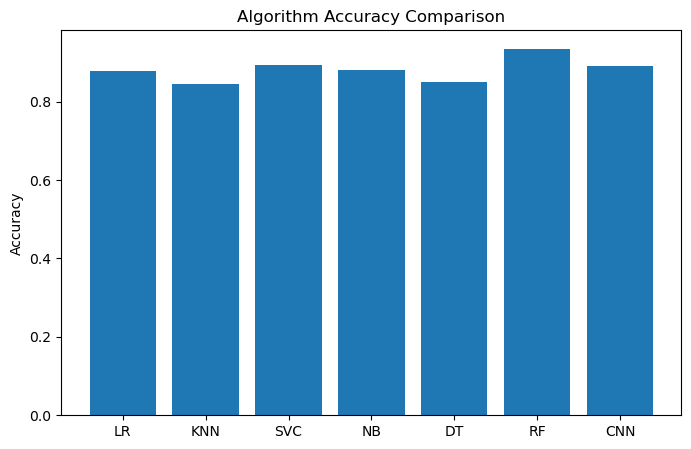

In [21]:
import matplotlib.pyplot as plt

algorithms = ['LR','KNN','SVC','NB','DT','RF','CNN']
scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_svc),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy
]

plt.figure(figsize=(8,5))
plt.bar(algorithms, scores)
plt.ylabel("Accuracy")
plt.title("Algorithm Accuracy Comparison")
plt.show()

In [23]:
import pickle
import os

os.chdir(r"D:\upi fraud detection\ai-engine")

pickle.dump(rf, open("fraud_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [24]:
import os

print(os.path.exists(r"D:\upi fraud detection\ai-engine\fraud_model.pkl"))
print(os.path.exists(r"D:\upi fraud detection\ai-engine\scaler.pkl"))

True
True


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)